Problem 1(b)

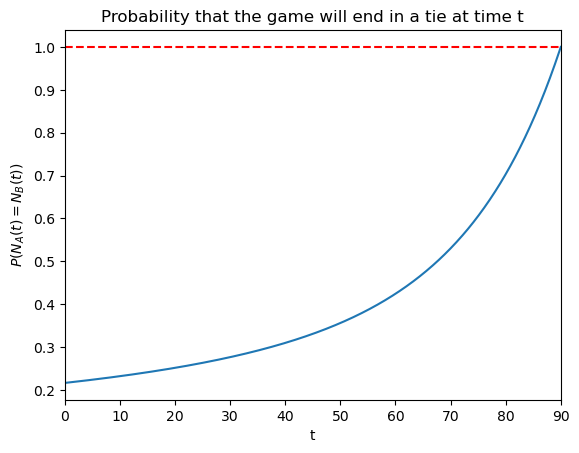

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

def f(t):
    s = 1 - t/90
    muA = 2*s
    muB = 1.5*s
    x = muA * muB
    
    S = 1.0
    term = 1.0
    
    for k in range(1, 1000):
        term *= x / (k**2)
        S += term
    
    return np.exp(-(muA + muB)) * S

t = np.linspace(0,90, 1000)


plt.plot(t, f(t))
plt.xlabel("t")
plt.ylabel(r"$P(N_A(t) = N_B(t))$")
plt.title("Probability that the game will end in a tie at time t")
plt.xlim(0,90)
plt.hlines(1, 0, 90, "r", "dashed")
plt.show()

Problem 1(c)

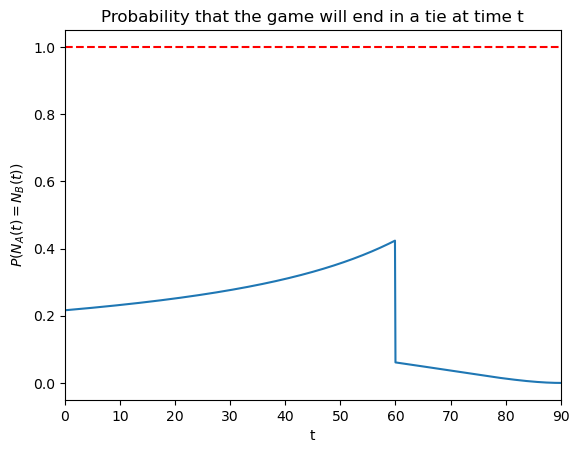

In [11]:
def tie_prob_before(t):
    s = 1 - t/90
    muA = 2*s
    muB = 1.5*s
    x = muA * muB
    
    S = 1.0
    term = 1.0
    
    for k in range(1, 1000):
        term *= x / (k**2)
        S += term
    
    return np.exp(-(muA + muB)) * S


def tie_prob_after(t):
    s = (90 - t)/90
    muA = 2*s
    muB = 1.5*s
    
    S = muB
    term = muB
    
    for k in range(0, 1000):
        term *= (muA * muB) / ((k+1)*(k+2))
        S += term
    
    return (1-t/90)*np.exp(-(muA + muB)) * S


def f(t):
    if t < 60:
        return tie_prob_before(t)
    else:
        return tie_prob_after(t)
    
t = np.linspace(0,90, 1000)


plt.plot(t, np.vectorize(f)(t))
plt.xlabel("t")
plt.ylabel(r"$P(N_A(t) = N_B(t))$")
plt.title("Probability that the game will end in a tie at time t")
plt.xlim(0,90)
plt.hlines(1, 0, 90, "r", "dashed")
plt.show()

Problem 2(c)

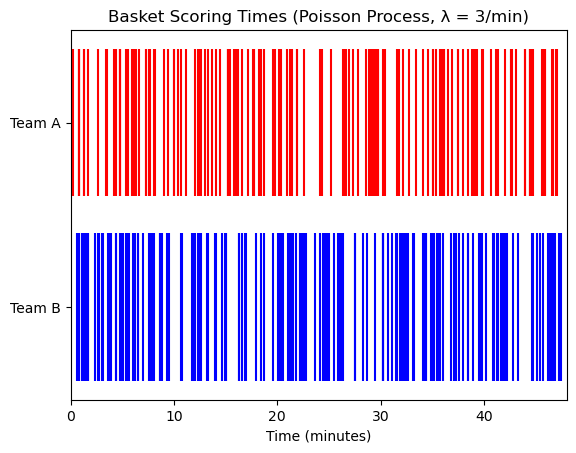

In [4]:
T = 48
lam = 3

def simulate_times(lam, T):
    times = []
    t = 0
    
    while True:
        t += np.random.exponential(1/lam)
        if t > T:
            break
        times.append(t)
    
    return np.array(times)

times_A = simulate_times(lam, T)
times_B = simulate_times(lam, T)

plt.eventplot(
    [times_A, times_B],
    colors=['red', 'blue'],
    lineoffsets=[1, 0],
    linelengths=0.8
)

plt.xlim(0, T)
plt.ylim(-0.5, 1.5)
plt.yticks([0, 1], ["Team B", "Team A"])
plt.xlabel("Time (minutes)")
plt.title("Basket Scoring Times (Poisson Process, λ = 3/min)")
plt.show()

Problem 2(d)

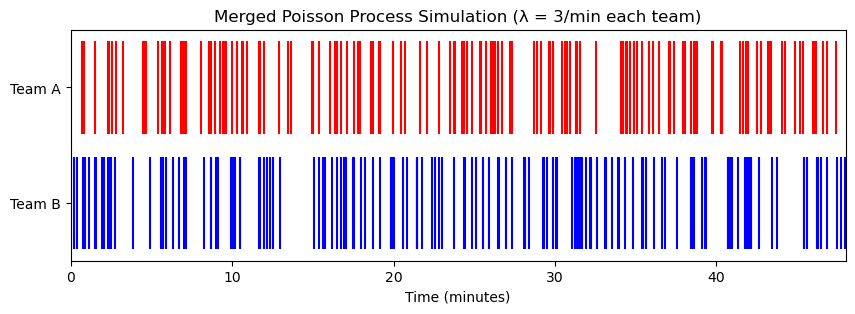

In [5]:
def simulate_merged(T, lam):
    times_A = []
    times_B = []
    
    t = 0
    
    while True:
        # total rate is 2λ
        t += np.random.exponential(1/(2*lam))
        if t > T:
            break
        
        # assign to team
        if np.random.rand() < 0.5:
            times_A.append(t)
        else:
            times_B.append(t)
    
    return np.array(times_A), np.array(times_B)

times_A, times_B = simulate_merged(T, lam)

plt.figure(figsize=(10, 3))

plt.eventplot(
    [times_A, times_B],
    colors=['red', 'blue'],
    lineoffsets=[1, 0],
    linelengths=0.8
)

plt.xlim(0, T)
plt.ylim(-0.5, 1.5)
plt.yticks([0, 1], ["Team B", "Team A"])
plt.xlabel("Time (minutes)")
plt.title("Merged Poisson Process Simulation (λ = 3/min each team)")
plt.show()

Problem 2(e)

In [6]:
lam = 3
t = 48
mu = 2*lam*t 

N = np.random.poisson(mu, size=10**5)
NA = np.random.binomial(N, 0.5)
NB = N - NA
D = 2 * (NA - NB)

ED = np.mean(D)
VarD = np.var(D)
P0 = np.mean(D == 0)

print("E[D(t)] ≈", ED)
print("Var[D(t)] ≈", VarD)
print("P(D(t)=0) ≈", P0)

E[D(t)] ≈ 0.04566
Var[D(t)] ≈ 1153.1855551643998
P(D(t)=0) ≈ 0.02431


Problem 3(a)

In [3]:
from scipy.integrate import quad

def integrand(t):
    return np.exp(-(t**3 + 2700*t)/5400)

result, error = quad(integrand, 0, np.inf)

print("Integral value:", result)
print("Estimated error:", error)

Integral value: 1.9835239394688795
Estimated error: 3.078423086356063e-11


Problem 3(c)

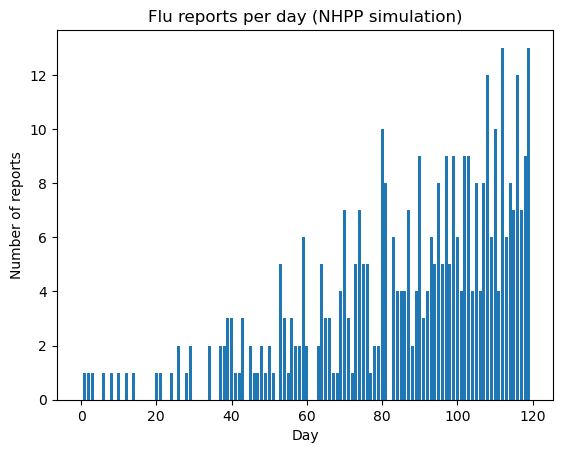

Total reports: 395


In [12]:
def lam(t):
    return 0.5 * (1 + (t/30)**2)

T = 120
lam_max = 8.5
t = 0
arrival_times = []

while t < T:
    t += np.random.exponential(1/lam_max)
    if t > T:
        break
    arrival_times.append(t)

arrival_times = np.array(arrival_times)
accepted_times = []
for ti in arrival_times:
    if np.random.rand() < lam(ti) / lam_max:
        accepted_times.append(ti)

accepted_times = np.array(accepted_times)

days = np.arange(0, 121)
counts, _ = np.histogram(accepted_times, bins=days)

plt.bar(days[:-1], counts)
plt.xlabel("Day")
plt.ylabel("Number of reports")
plt.title("Flu reports per day (NHPP simulation)")
plt.show()

print("Total reports:", len(accepted_times))